In [1]:
from gwosc.datasets import find_datasets
import bilby
from gwpy.timeseries import TimeSeries
from gwosc import datasets
import numpy as np
import os.path
import os
from os import path
import glob
import re

/home/alex-pottie/Uni/Project/GWPopulationExtraction/.venv/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [2]:
files = [file for file in glob.glob("../Data/*/*.json")]
results = {}
for file_name in files:
    result = bilby.result.read_in_result(filename=file_name, result_class=bilby.gw.result.CBCResult)
    try:
        results[re.search("GW......_......", file_name).group()] = result
    except:
        results[re.search("GW......", file_name).group()] = result

16:08 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
16:08 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
16:08 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
16:08 bilby INFO    : Global meta data was removed from the result object for compatibility

In [14]:
from matplotlib import pyplot as plt

evidence = []

for result in results:
    evidence.append(result.log_noise_evidence)

for result in results:
    if result.log_noise_evidence == max(evidence):
        print(result.posterior["mass_1_source"].quantile(0.5))
        result.posterior

ValueError: Result object has no stored posterior

In [19]:
num = 0
count = 0

events = []
for result in results:
    if results[result].posterior["mass_1_source"].quantile(0.5) > 60 or results[result].posterior["mass_2_source"].quantile(0.5) > 60:
        num += 1
        events.append(result)

    count += 1

print(events)

['GW200220_061928', 'GW230601_224134', 'GW190521_030229', 'GW190706_222641', 'GW231206_010629', 'GW190725_174728', 'GW230702_162025', 'GW230708_230935', 'GW190720_000836', 'GW231028_153006', 'GW190426_190642', 'GW230814_061920', 'GW190602_175927', 'GW231029_111508', 'GW230824_135331', 'GW230608_205047', 'GW231001_140220', 'GW230922_040658', 'GW191109_010717', 'GW230704_212616', 'GW230807_205045', 'GW231005_021030', 'GW231204_090648', 'GW231123_135430', 'GW230728_083628', 'GW200208_222617', 'GW230707_124047', 'GW240105_151143', 'GW190519_153544']


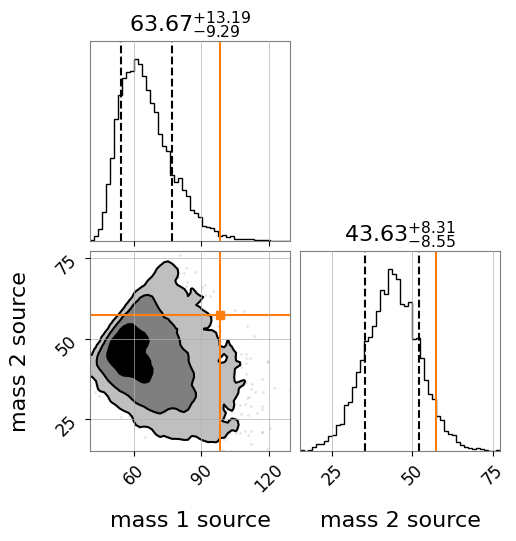

In [18]:
key = "GW231029_111508"
truths_mass = [98.4, 57.2]
results[key].plot_corner(['mass_1_source', 'mass_2_source'], color = 'black', truths=truths_mass, outdir="./Graphs")

In [30]:
results[key].posterior

,chirp_mass,mass_ratio,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,dec,ra,...,chi_2_in_plane,chi_p,cos_tilt_1,cos_tilt_2,redshift,comoving_distance,mass_1_source,mass_2_source,chirp_mass_source,total_mass_source
0,31.247804,0.313633,0.613750,0.287031,1.954483,1.989540,3.659371,2.474741,-1.075024,6.105017,...,0.262232,0.569125,-0.374342,-0.406613,0.455305,1793.313494,45.468178,14.260303,21.471653,59.728481
1,57.876508,0.806053,0.477318,0.713586,0.646824,0.576301,0.345397,0.247181,0.672258,2.157922,...,0.388851,0.303964,0.798002,0.838484,0.732696,2675.061596,42.786601,34.488287,33.402577,77.274888
2,50.177230,0.811703,0.270643,0.962675,0.722430,1.487847,3.010736,5.040174,0.419824,2.002741,...,0.959365,0.755933,0.750201,0.082854,0.577350,2199.551702,40.602983,32.957547,31.811102,73.560529
3,36.288954,0.760038,0.280088,0.110225,1.181327,1.440554,0.427237,5.438187,0.001730,4.112024,...,0.109291,0.259112,0.379698,0.129875,0.636470,2385.819674,29.273155,22.248720,22.175142,51.521875
4,42.967299,0.442611,0.127321,0.518122,1.201822,2.949591,4.262843,4.269139,0.977616,2.973187,...,0.098870,0.118752,0.360659,-0.981624,0.668698,2484.579995,45.183202,19.998564,25.748994,65.181766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10200,26.432222,0.325372,0.340065,0.388882,2.872222,2.202923,2.878456,4.204527,0.592094,1.949039,...,0.313739,0.090500,-0.963939,-0.590862,0.501987,1952.236056,36.517993,11.881932,17.598167,48.399925
10201,26.432222,0.325372,0.340065,0.388882,2.872222,2.202923,2.878456,4.204527,0.592094,1.949039,...,0.313739,0.090500,-0.963939,-0.590862,0.417069,1659.799920,38.706352,12.593962,18.652746,51.300314
10202,24.659225,0.333227,0.885062,0.675613,2.528514,1.479434,5.283559,6.093272,0.825510,2.300489,...,0.672795,0.509254,-0.817881,0.091235,0.276884,1143.842785,39.551676,13.179676,19.312033,52.731352
10203,24.954746,0.282658,0.680414,0.553098,2.249307,1.684784,2.647899,5.814467,0.825857,2.241233,...,0.549508,0.529708,-0.627634,-0.113741,0.327669,1335.621382,42.162754,11.917636,18.795915,54.080389
